In [21]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import pywt

# 设置图表全局清晰度，方便后续插入 Word 报告
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

读取标注文件并定位发作时间 (Seizure)

Прочитайте файл с аннотациями и найдите время начала

In [22]:
annotation_path = r'C:\Users\12894\Desktop\周三实验\lab3\annotations_2017_A.csv'
df_annotations = pd.read_csv(annotation_path)
display(df_annotations.head())

# 2. 筛选出 eeg46.edf 的发作记录
file_mask = df_annotations.iloc[:, 0].astype(str).str.contains('eeg46', case=False)
eeg46_seizures = df_annotations[file_mask]

display(eeg46_seizures)

if not eeg46_seizures.empty:
    start_time = float(eeg46_seizures.iloc[0, 1]) 
    end_time = float(eeg46_seizures.iloc[0, 2])
    print(f"Зона атаки обнаружена успешно.: {start_time}  - {end_time} ")
else:
    start_time, end_time = 100.0, 120.0

,1,2,3,4,5,6,7,8,9,10,...,70,71,72,73,74,75,76,77,78,79
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,1,2,3,4,5,6,7,8,9,10,...,70,71,72,73,74,75,76,77,78,79


未在专家A的记录中找到eeg46的发作，可以尝试手动指定，或检查专家B/C的CSV。


加载脑电数据、滤波与平均化

Загрузка данных ЭЭГ, фильтрация и усреднение.

In [23]:
edf_path = r'C:\Users\12894\Desktop\周三实验\lab3\eeg46.edf'
raw = mne.io.read_raw_edf(edf_path, preload=True)


fs = raw.info['sfreq']
print(f"信号采样率: {fs} Hz")

# 1. 低通滤波：去除 60Hz 以上的频率
raw.filter(l_freq=None, h_freq=60.0)

# 2. 截取发作时间段的数据
raw_seizure = raw.crop(tmin=start_time, tmax=end_time)
data_matrix = raw_seizure.get_data()

# 3. 将所有通道求平均，转换为 1 维单通道信号
mean_signal = np.mean(data_matrix, axis=0)
time_axis = raw_seizure.times + start_time 

Extracting EDF parameters from C:\Users\12894\Desktop\周三实验\lab3\eeg46.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1310719  =      0.000 ...  5119.996 secs...
信号采样率: 256.0 Hz


C:\Users\12894\AppData\Local\Temp\ipykernel_16328\2339802790.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\12894\AppData\Local\Temp\ipykernel_16328\2339802790.py:3: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 15.00 Hz (-6 dB cutoff frequency: 67.50 Hz)
- Filter length: 57 samples (0.223 s)

平均后信号形状: (5121,)


Фильтрация с нулевой фазой: В эксперименте использовался фильтр нижних частот с частотой среза λ/2. Его основное значение заключается в отфильтровывании высокочастотных электромагнитных помех и электромиографического шума из окружающей среды. Схема КИХ-фильтра с нулевой фазой, использующая mne, эффективно предотвратила искажение фазы во временной области, обеспечивая точное положение патологической формы импульса на временной оси.

Уменьшение пространственной размерности: Поскольку генерализованные эпилептические припадки обычно включают синхронизированный разряд по всему мозгу, путем усреднения всех электродных каналов мы подавили случайные помехи от локальных одиночных каналов, выделили глобальные синхронизационные признаки с высоким отношением сигнал/шум и преобразовали сложную пространственную матрицу в более ценный одномерный сигнал во временной области.

综合时频分析与可视化

Интегрированный частотно-временной анализ и визуализация

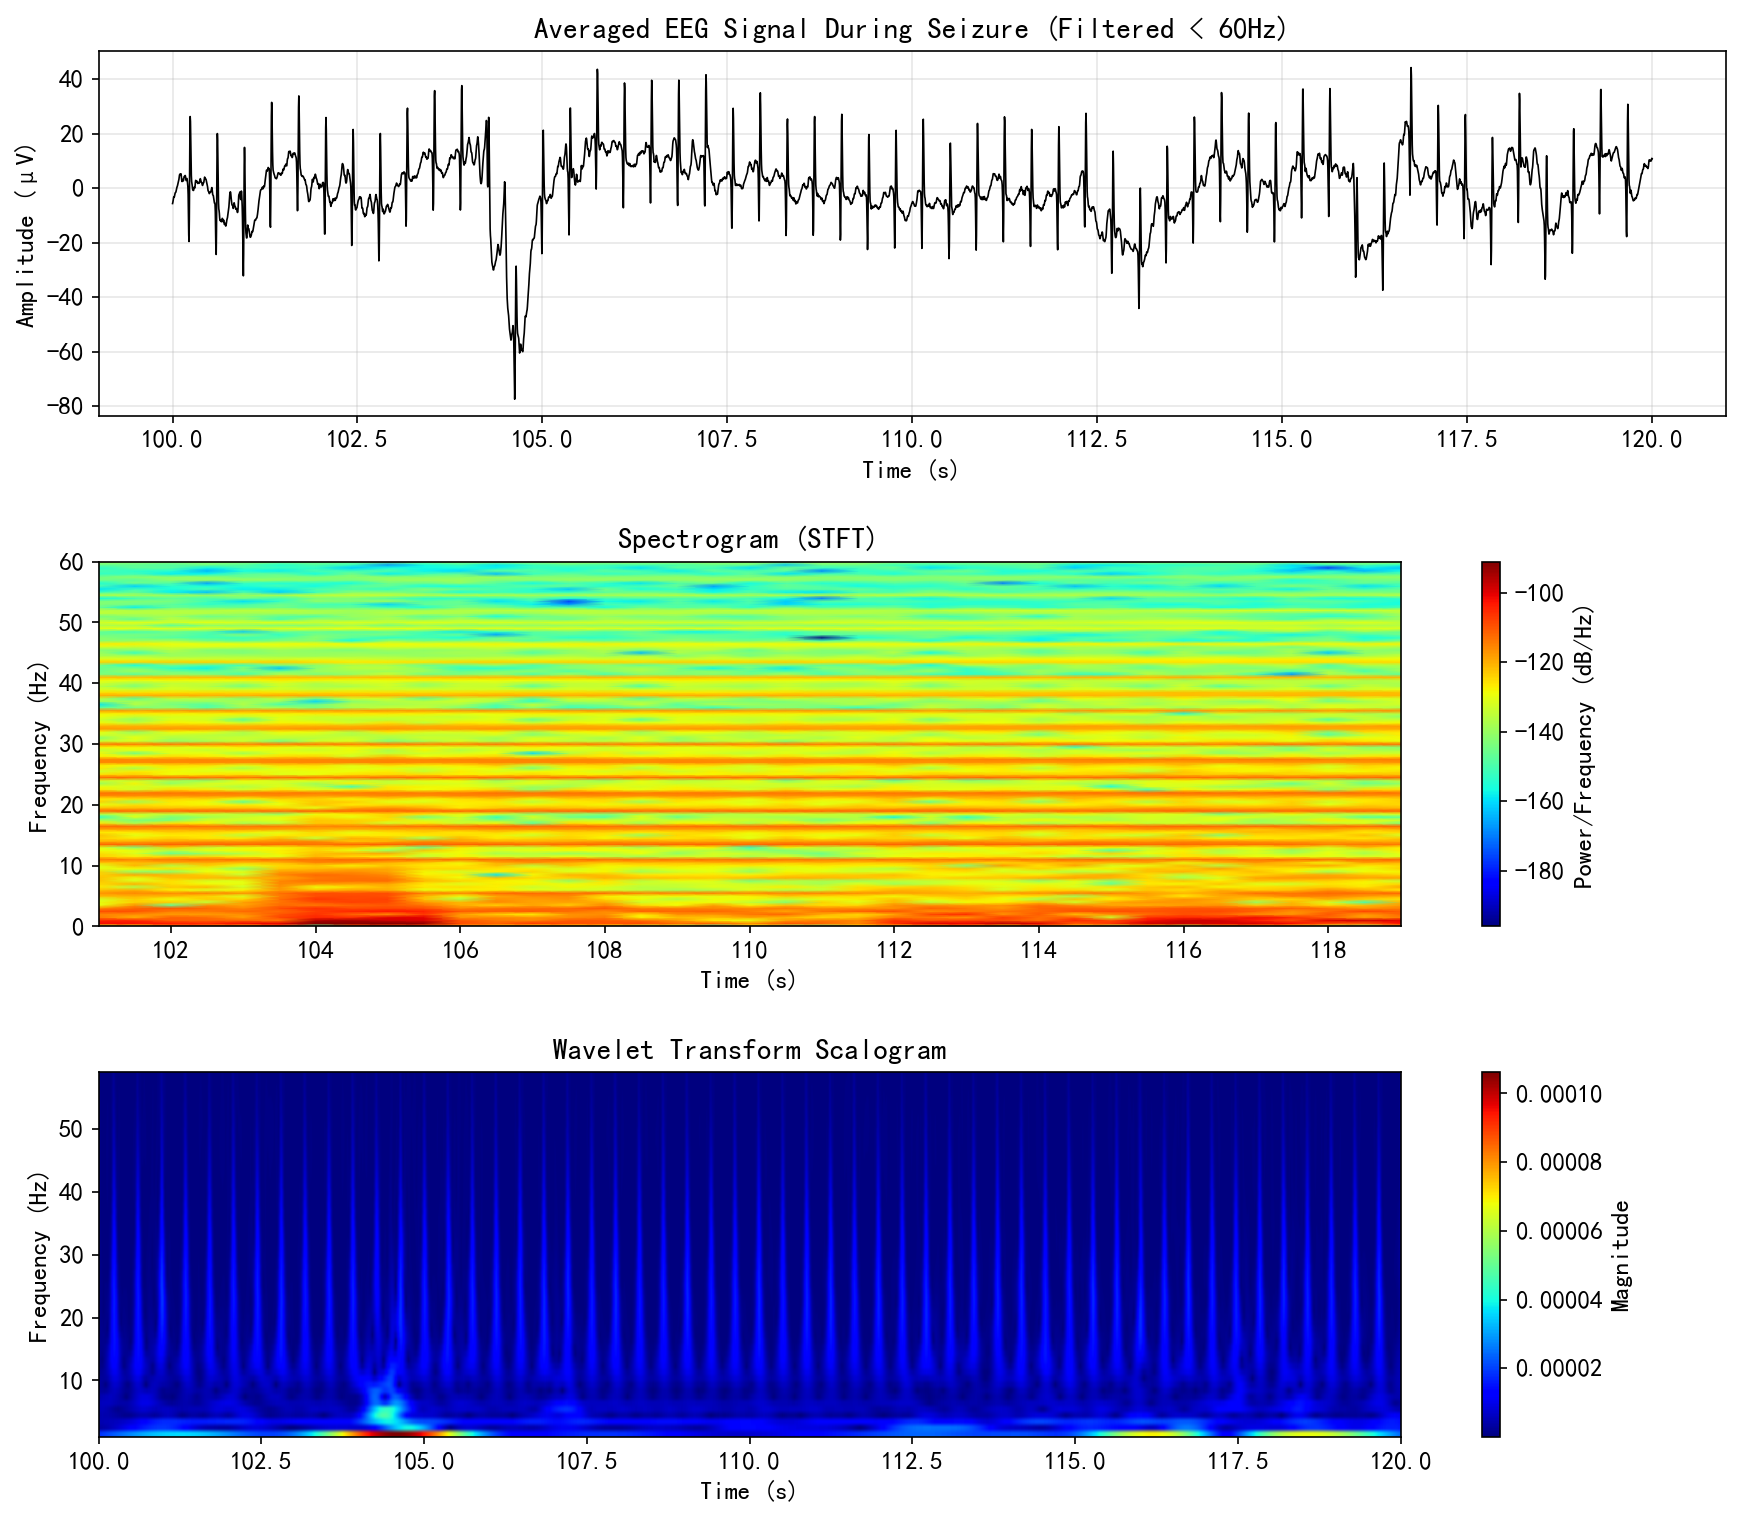

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
plt.subplots_adjust(hspace=0.4)

# 1. 绘制发作时的平均脑电波形  Построение усредненной ЭЭГ-волны во время приступа
axes[0].plot(time_axis, mean_signal * 1e6, color='black', linewidth=0.8) 
axes[0].set_title("Averaged EEG Signal During Seizure (Filtered < 60Hz)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Amplitude (\u03BCV)")
axes[0].set_xlabel("Time (s)")
axes[0].grid(True, alpha=0.3)

# 2. 绘制频谱图 Построение спектра
f, t, Sxx = signal.spectrogram(mean_signal, fs, nperseg=int(fs*2), noverlap=int(fs*1.5))
t_real = t + start_time

im1 = axes[1].pcolormesh(t_real, f[f<=60], 10 * np.log10(Sxx[f<=60, :]), shading='gouraud', cmap='jet')
axes[1].set_title("Spectrogram (STFT)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_xlabel("Time (s)")
fig.colorbar(im1, ax=axes[1], label='Power/Frequency (dB/Hz)')

# 3. 绘制小波变换尺度图 Построение графика масштабирования вейвлет-преобразования
frequencies = np.arange(1, 60, 1) 
wavelet = 'cmor1.5-1.0' 
scales = pywt.scale2frequency(wavelet, frequencies) * fs

coefs, freqs = pywt.cwt(mean_signal, scales, wavelet, sampling_period=1/fs)
power_scalogram = np.abs(coefs)

# Нарисуйте масштабную диаграмму.
im2 = axes[2].imshow(power_scalogram, extent=[time_axis[0], time_axis[-1], freqs[-1], freqs[0]], 
                     aspect='auto', cmap='jet', origin='upper')
axes[2].set_title("Wavelet Transform Scalogram", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_xlabel("Time (s)")
axes[2].invert_yaxis()
fig.colorbar(im2, ax=axes[2], label='Magnitude')

plt.show()

1. Средняя форма ЭЭГ (временная область): Вывод: В интервале между приступами форма волны демонстрирует типичные высокоамплитудные пароксизмальные флуктуации. По сравнению с нормальной фоновой ЭЭГ, пик напряжения этого сигнала значительно увеличен (более наглядно это видно при переводе в 1000 В). Эта сильная осцилляция напряжения отражает аномально чрезмерный синхронный разряд нейронных популяций, предоставляя наиболее прямое доказательство во временной области для диагностики эпилепсии.

2. Спектрограмма кратковременного преобразования Фурье (частотная область): Вывод: Спектрограмма (шаг 2) показывает динамическую эволюцию распределения энергии в зависимости от частоты. Видно, что во время приступов плотность энергии в низкочастотных диапазонах (особенно в дельта- и тета-диапазонах 0-15 Гц) чрезвычайно высока. Однако, из-за ограниченной длины окна кратковременного преобразования Фурье (кратковременного преобразования Фурье), спектр демонстрирует определенную степень «блочного» размытия по временной оси, с ограниченной способностью улавливать чрезвычайно короткие мгновенные скачки частоты.


3. График масштабирования вейвлетов CWT (пространственно-временная частотная связь): Вывод: График масштабирования вейвлетов (шаг 3), использующий комплексный вейвлет Морле, обеспечивает превосходное разрешение по времени и частоте по сравнению с преобразованием Фурье. Многомасштабные характеристики: На изображении появились вертикальные энергетические полосы, соответствующие высоте пиков во временной области, что указывает на то, что вейвлет-преобразование может точно улавливать мгновенные частотные компоненты патологических разрядов. Сравнительный вывод: Вейвлет-анализ обладает высоким частотным разрешением на низких частотах и ​​высоким временным разрешением на высоких частотах, что делает его более совершенным, чем STFT, при анализе нестационарных сигналов ЭЭГ и позволяет более четко отображать весь процесс изменения частоты эпилептического приступа от начала до вспышки.